# Modélisation du risque de crédit par chaînes de Markov

## Estimation des transitions IFRS 9 (Stages S1 / S2 / S3) — 2018-2024

**Auteur :** Youssef Rais

**Contexte :** Stage à la Banque de Tunisie (Juillet 2025)

**Domaine :** Risque de crédit · IFRS 9 · Expected Credit Loss (ECL)

---

## 1. Contexte et objectifs

Depuis l'entrée en vigueur de la norme comptable **IFRS 9** (2018), les banques doivent provisionner leurs créances (le terme créance désigne tout simplement l'argent qu'une personne, une entreprise ou un État doit à la banque) selon une logique **forward-looking** appelée *Expected Credit Loss* (ECL). Chaque encours(le montant total des sommes dues à la banque à un instant T) est classé dans l'un des trois **stages** :

| Stage | Définition opérationnelle | Provision |
|-------|---------------------------|-----------|
| **S1** | Crédit performant : paiements à jour | 12-month ECL |
| **S2** | Détérioration significative du risque : 1 à 3 mois d'impayés | Lifetime ECL |
| **S3** | Défaut avéré : plus de 3 mois d'impayés, recouvrement contentieux engagé | Lifetime ECL + provision défaut |

L'objectif de cette étude est de :

1. **Estimer les matrices de transition annuelles** entre stages sur la période 2018-2024 (7 ans).
2. **Construire un modèle de Markov** pour projeter l'évolution de la structure du portefeuille à moyen et long terme.
3. **Identifier la distribution stationnaire** du processus, qui correspond à la structure d'équilibre du portefeuille sous hypothèse de stabilité des comportements.

### Pourquoi 7 ans ?

La fenêtre de 7 ans (2018-2024) correspond à un **cycle économique court à moyen** au sens des cycles de Juglar (7-11 ans). Cette durée permet de capturer à la fois des périodes d'expansion (2018-2019), de crise exogène (2020 — COVID-19), et de reprise progressive (2021-2024). En estimant les matrices année par année puis en les agrégeant, on capture une dynamique de transition **moyennée sur un cycle** plutôt qu'une photographie ponctuelle potentiellement biaisée.

> ⚠️ **Note sur les données :** les données utilisées proviennent du système d'information de la Banque de Tunisie et contiennent des informations clients confidentielles. Cette version publique du notebook **n'expose aucun identifiant client** : seules les matrices de transition agrégées sont conservées.

## 2. Chargement des données et préparation

### 2.1 Description du jeu de données

Les fichiers source sont structurés comme suit (un fichier par année) :

| Colonne | Description |
|---------|-------------|
| `CRIANNEE` | Année de l'observation |
| `CRIMOIS` | Mois de fin de trimestre (3, 6, 9, 12) |
| `CPGTID` | Code agence (lettre) |
| `CPGNID` | Identifiant numérique client |
| `CRICSDEF` | Code de classification du défaut (0 = sain, 1-2 = retard léger, 3+ = défaut) |
| `SNISGCOD` | Code segment (particulier / entreprise / etc.) |

Les données sont **trimestrielles** : pour chaque client en portefeuille, on dispose de 4 observations par an (mars, juin, septembre, décembre).

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import matrix_power, eig

# Configuration des affichages
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Chargement des données (format Parquet pour des performances optimales sur gros volumes)
data_2018 = pd.read_parquet('data_2018.parquet')
data_2019 = pd.read_parquet('data_2019.parquet')
data_2020 = pd.read_parquet('data_2020.parquet')
data_2021 = pd.read_parquet('data_2021.parquet')
data_2022 = pd.read_parquet('data_2022.parquet')
data_2023 = pd.read_parquet('data_2023.parquet')
data_2024 = pd.read_parquet('data_2024.parquet')

#Pour executer le notebook localement ajouter source\data_2018.parquet,...

data_2018.head(5)

,Unnamed: 0,CRIANNEE,CRIMOIS,CPGTID,CPGNID,id,CRICSDEF,stage,SNISGCOD
0,0,2017,12,E,83,E83,1,S2,6
1,1,2017,12,E,345,E345,0,S1,6
2,2,2017,12,E,361,E361,0,S1,6
3,3,2017,12,E,459,E459,0,S1,6
4,4,2017,12,E,639,E639,4,S3,6


**Choix technique - Parquet plutôt qu'Excel.** Les fichiers Excel sources (`notes2018.xlsx` à `notes2024.xlsx`) étaient lourds et lents à charger (> 30 secondes par fichier).

### 2.2 Construction de la variable `stage` (IFRS 9)

La classification IFRS 9 dépend du nombre de mois d'impayés. Dans le système de la banque, la variable `CRICSDEF` encode cette information :

- `CRICSDEF = 0` → aucun retard → **Stage 1** (performant)
- `CRICSDEF = 1` ou `2` → 1 à 2 mois d'impayés → **Stage 2** (détérioration)
- `CRICSDEF ≥ 3` → 3 mois et plus d'impayés → **Stage 3** (défaut)

In [11]:
def classer_stage(csdef):
    #Classifie un encours selon les stages IFRS 9 à partir du code CRICSDEF.
    if csdef == 0:
        return 'S1'
    elif csdef == 1:
        return 'S2'
    else:
        return 'S3'

# Application sur chaque dataset annuel
for df in [data_2018, data_2019, data_2020, data_2021, data_2022, data_2023, data_2024]:
    df['stage'] = df['CRICSDEF'].apply(classer_stage)

# Vérification rapide sur 2018
print("Répartition des stages en 2018 (toutes observations trimestrielles confondues) :")
print(data_2018['stage'].value_counts())
print()
print("Soit en proportion :")
print(data_2018['stage'].value_counts(normalize=True).round(4))

Répartition des stages en 2018 (toutes observations trimestrielles confondues) :
stage
S1    278027
S3     60256
S2      7868
Name: count, dtype: int64

Soit en proportion :
stage
S1   0.8032
S3   0.1741
S2   0.0227
Name: proportion, dtype: float64


**Résultat observé (2018) :**

| Stage | Nb observations | Proportion |
|-------|----------------|------------|
| S1 | 278 027 | 80 % |
| S2 | 7 868 | 2 % |
| S3 | 60 256 | 17 % |

> **Interprétation :** Le portefeuille est dominé par les crédits sains (S1), ce qui est attendu pour une banque commerciale. La forte proportion de S3 (~17 %) est notable : elle reflète l'existence d'un **stock historique de créances en défaut non encore éliminé**.

### 2.3 Création d'un identifiant unique client

L'identifiant client est composite : il faut concaténer le code agence (`CPGTID`) et le numéro client (`CPGNID`) pour disposer d'une clé primaire fiable et permettre le suivi inter-trimestriel.

In [12]:
# Construction de l'ID unique : agence + numéro client
for df in [data_2018, data_2019, data_2020, data_2021, data_2022, data_2023, data_2024]:
    df['id'] = df['CPGTID'].astype(str) + df['CPGNID'].astype(str)

# Vérification : combien de clients uniques en 2019 ?
print(f"Nombre de clients uniques en 2019 : {data_2019['id'].nunique():,}")

Nombre de clients uniques en 2019 : 95,992


**Résultat :** 95 992 clients uniques en 2019. Ce chiffre est cohérent avec la taille d'un portefeuille bancaire de banque commerciale de taille moyenne.

## 3. Construction des matrices de transition annuelles

### 3.1 Méthodologie

Pour chaque année $y$, nous calculons la matrice de transition $M_y$ qui donne la probabilité qu'un client en stage $i$ au début de l'année soit en stage $j$ à la fin :

$$M_y[i,j] = \mathbb{P}(\text{stage}_{T_4} = j \mid \text{stage}_{T_1} = i)$$

**Approche par composition trimestrielle.** Plutôt que d'estimer directement la transition annuelle T1→T4, on estime les **3 transitions trimestrielles** T1→T2, T2→T3, T3→T4 puis on les compose :

$$M_y = M_{T_1 \to T_2} \cdot M_{T_2 \to T_3} \cdot M_{T_3 \to T_4}$$

**Hypothèse:** propriété de Markov (l'état futur ne dépend que de l'état présent, pas du passé) et indépendance entre les transitions trimestrielles successives.


In [13]:
def matrice_de_transition(data):
    """
    Calcule la matrice de transition annuelle S1/S2/S3 à partir des observations trimestrielles.

    Méthode / étapes:
    1. Pour chaque trimestre Ti (i = 1, 2, 3, 4), extraire la liste (id_client, stage).
    2. Joindre les couples (Ti, Ti+1) sur l'identifiant client → seuls les clients
       présents aux deux dates sont conservés (jointure interne).
    3. Construire la matrice de contingence des transitions via crosstab.
    4. Normaliser ligne par ligne pour obtenir des probabilités conditionnelles.
    5. Composer les 3 matrices trimestrielles pour obtenir la transition annuelle.
    """
    # Étape 1 : extraction des snapshots trimestriels (mois 3, 6, 9, 12)
    T1 = data[data['CRIMOIS'] == 3][['id', 'stage']]
    T2 = data[data['CRIMOIS'] == 6][['id', 'stage']]
    T3 = data[data['CRIMOIS'] == 9][['id', 'stage']]
    T4 = data[data['CRIMOIS'] == 12][['id', 'stage']]

    # Étape 2 : jointures sur l'identifiant client pour suivre la trajectoire individuelle
    # Une jointure interne (default merge) exclut les clients entrant/sortant en cours d'année.
    T1_T2 = pd.merge(T1, T2, on='id', suffixes=('_T1', '_T2'))
    T2_T3 = pd.merge(T2, T3, on='id', suffixes=('_T2', '_T3'))
    T3_T4 = pd.merge(T3, T4, on='id', suffixes=('_T3', '_T4'))

    # Étape 3 : construction des matrices de contingence (effectifs)
    M_T1_T2 = pd.crosstab(T1_T2['stage_T1'], T1_T2['stage_T2'])
    M_T2_T3 = pd.crosstab(T2_T3['stage_T2'], T2_T3['stage_T3'])
    M_T3_T4 = pd.crosstab(T3_T4['stage_T3'], T3_T4['stage_T4'])

    # Étape 4 : normalisation ligne par ligne → probabilités conditionnelles
    # Chaque ligne doit sommer à 1 (loi totale des probabilités).
    M_T1_T2 = M_T1_T2.div(M_T1_T2.sum(axis=1), axis=0)
    M_T2_T3 = M_T2_T3.div(M_T2_T3.sum(axis=1), axis=0)
    M_T3_T4 = M_T3_T4.div(M_T3_T4.sum(axis=1), axis=0)

    # Étape 5 : composition matricielle pour obtenir la transition annuelle
    M = M_T1_T2 @ M_T2_T3 @ M_T3_T4

    return M


# Calcul des 7 matrices annuelles
Mt_2018 = matrice_de_transition(data_2018)
Mt_2019 = matrice_de_transition(data_2019)
Mt_2020 = matrice_de_transition(data_2020)
Mt_2021 = matrice_de_transition(data_2021)
Mt_2022 = matrice_de_transition(data_2022)
Mt_2023 = matrice_de_transition(data_2023)
Mt_2024 = matrice_de_transition(data_2024)

print("Matrices de transition calculées pour chaque année de 2018 à 2024.")

Matrices de transition calculées pour chaque année de 2018 à 2024.


### 3.2 Résultats : les 7 matrices de transition annuelles

#### Matrice 2018

In [14]:
Mt_2018

stage_T4,S1,S2,S3
stage_T1,,,
S1,0.9675,0.0158,0.0167
S2,0.5908,0.0277,0.3815
S3,0.0887,0.0309,0.8804



**Analyse :**
- Un client en S1 début 2018 a **96,75 %** de chances d'être encore en S1 en fin d'année.
- Un client en S2 a une probabilité élevée (**59 %**) de **retourner en S1** (recouvrement réussi), mais aussi **38 %** de basculer en S3 (le S2 est intrinsèquement instable).
- Un client en S3 reste en S3 dans **88 %** des cas — caractéristique de la persistance du défaut.

#### Matrice 2019

In [15]:
Mt_2019

stage_T4,S1,S2,S3
stage_T1,,,
S1,0.9657,0.0163,0.0180
S2,0.6641,0.0240,0.3119
S3,0.0892,0.0286,0.8822


#### Matrice 2020 (année COVID)

In [16]:
Mt_2020

stage_T4,S1,S2,S3
stage_T1,,,
S1,0.9727,0.0103,0.0171
S2,0.5931,0.0218,0.3850
S3,0.0892,0.0303,0.8805


#### Matrice 2021

In [17]:
Mt_2021

stage_T4,S1,S2,S3
stage_T1,,,
S1,0.9668,0.0104,0.0228
S2,0.6933,0.0169,0.2898
S3,0.0982,0.0247,0.8771


#### Matrice 2022

In [18]:
Mt_2022

stage_T4,S1,S2,S3
stage_T1,,,
S1,0.9809,0.0036,0.0155
S2,0.6657,0.0138,0.3206
S3,0.1584,0.0070,0.8346


#### Matrice 2023

In [19]:
Mt_2023

stage_T4,S1,S2,S3
stage_T1,,,
S1,0.9757,0.0082,0.0162
S2,0.6065,0.0150,0.3785
S3,0.1632,0.0102,0.8266


#### Matrice 2024

In [20]:
Mt_2024

stage_T4,S1,S2,S3
stage_T1,,,
S1,0.9748,0.0041,0.0212
S2,0.6854,0.0133,0.3013
S3,0.1504,0.0083,0.8413


### 3.3 Analyse comparée des 7 matrices

Pour comparer les matrices entre années, on extrait les **probabilités-clés** :

| Année | P(S1→S1) | P(S2→S3) | P(S3→S3) | P(S3→S1) |
|-------|----------|----------|----------|----------|
| 2018 | 96,75 % | 38,15 % | 88,04 % | 8,87 % |
| 2019 | 96,57 % | 31,19 % | 88,22 % | 8,92 % |
| 2020 | 97,27 % | 38,50 % | 88,05 % | 8,92 % |
| 2021 | 96,68 % | 28,98 % | 87,71 % | 9,82 % |
| 2022 | 98,09 % | 32,06 % | 83,46 % | 15,84 % |
| 2023 | 97,57 % | 37,85 % | 82,66 % | 16,32 % |
| 2024 | 97,48 % | 30,13 % | 84,13 % | 15,04 % |

**Lectures principales :**

1. **Stabilité du S1 (96-98 %)** : le portefeuille performant est très "collant", ce qui est rassurant pour la banque. Cela traduit une bonne sélection de la personne qui prendra le crédit.

2. **Volatilité du S2 (29-38 % vers S3)** : le stage 2 est instable, ce qui est cohérent avec sa définition même (zone d'alerte). Le taux de bascule en défaut varie fortement, ce qui peut servir d'**indicateur avancé** du risque.


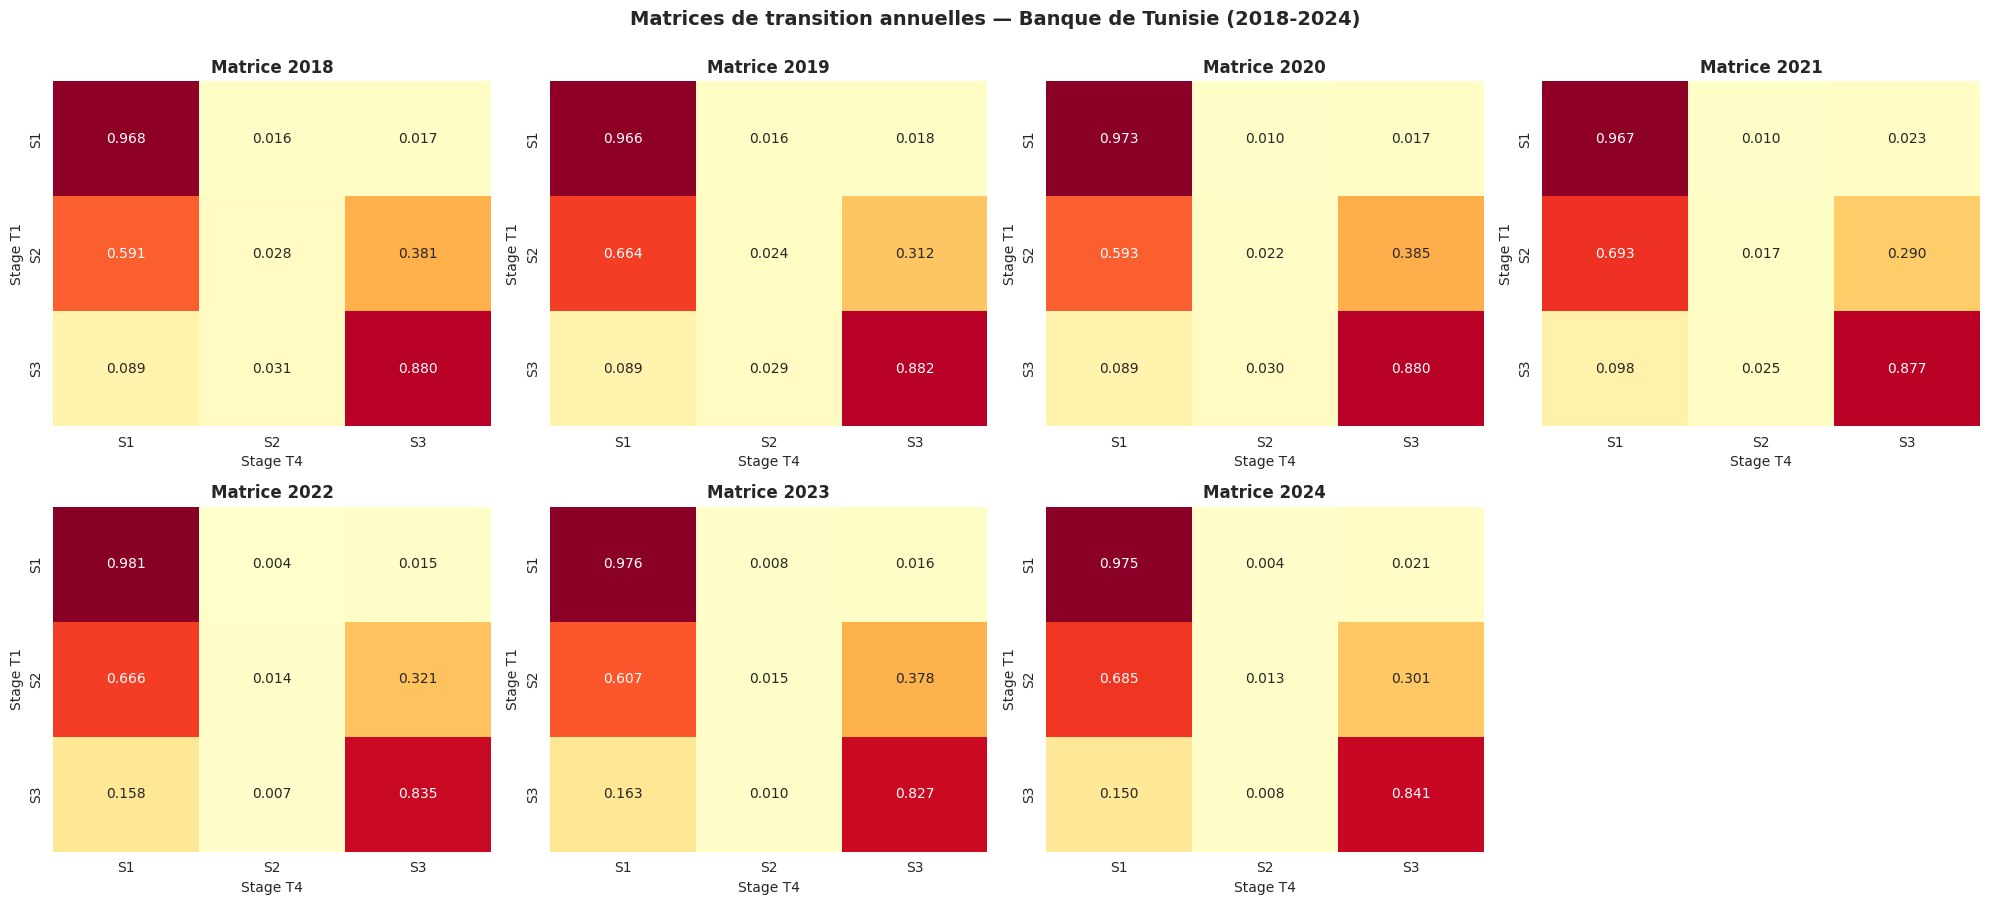

In [21]:
# Visualisation comparée des 7 matrices
matrices = {
    2018: Mt_2018, 2019: Mt_2019, 2020: Mt_2020, 2021: Mt_2021,
    2022: Mt_2022, 2023: Mt_2023, 2024: Mt_2024
}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, (year, M) in enumerate(matrices.items()):
    sns.heatmap(M, annot=True, fmt='.3f', cmap='YlOrRd',
                vmin=0, vmax=1, cbar=False, ax=axes[i],
                xticklabels=['S1', 'S2', 'S3'], yticklabels=['S1', 'S2', 'S3'])
    axes[i].set_title(f'Matrice {year}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Stage T4')
    axes[i].set_ylabel('Stage T1')

# Cellule vide pour l'esthétique (7 matrices sur 8 emplacements)
axes[7].axis('off')

plt.suptitle('Matrices de transition annuelles — Banque de Tunisie (2018-2024)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

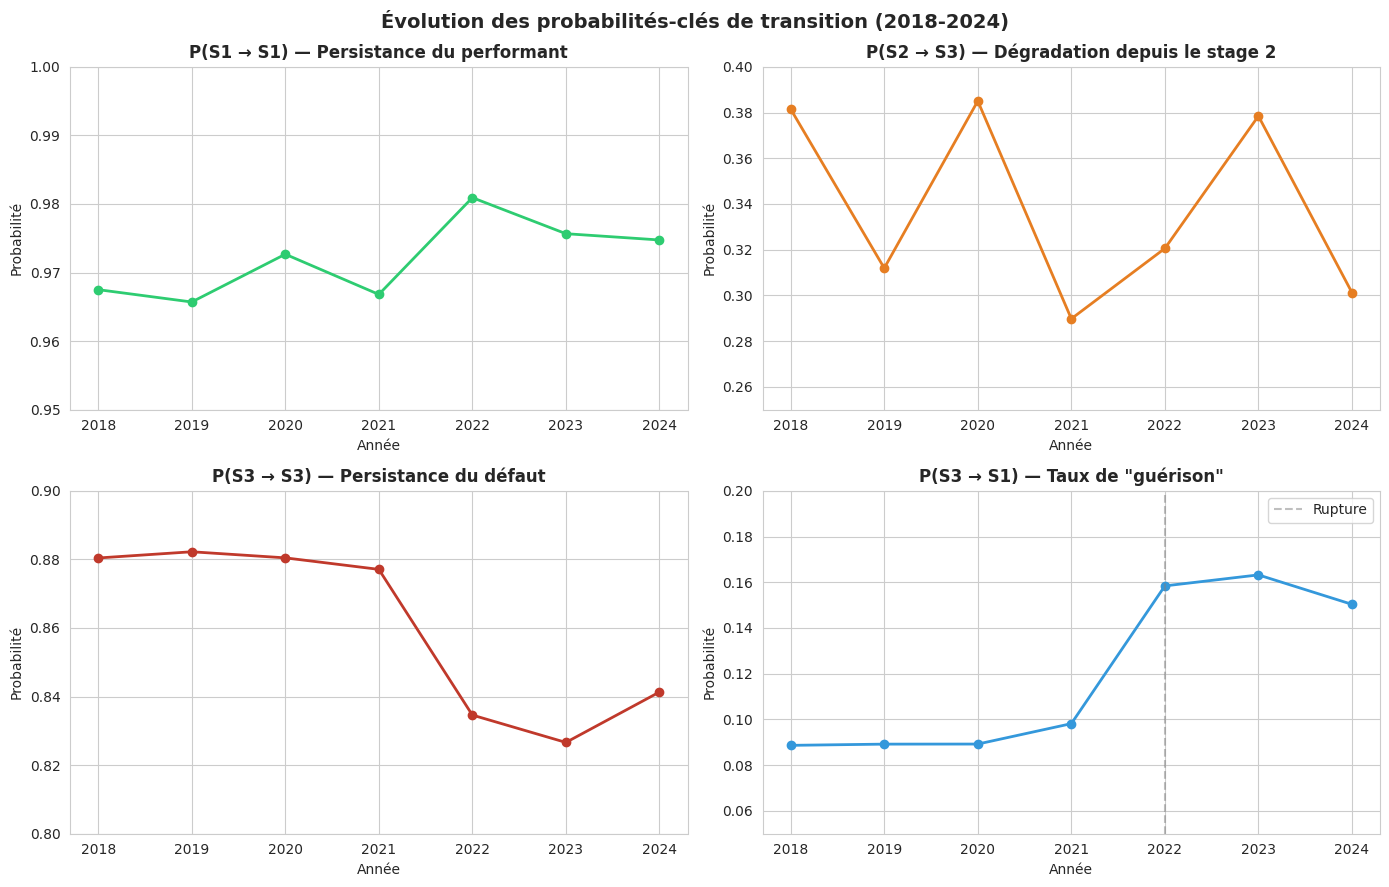

In [22]:
# Visualisation des probabilités-clés au cours du temps
import numpy as np

years = list(matrices.keys())
p_s1_s1 = [matrices[y].loc['S1', 'S1'] for y in years]
p_s2_s3 = [matrices[y].loc['S2', 'S3'] for y in years]
p_s3_s3 = [matrices[y].loc['S3', 'S3'] for y in years]
p_s3_s1 = [matrices[y].loc['S3', 'S1'] for y in years]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(years, p_s1_s1, 'o-', color='#2ecc71', linewidth=2)
axes[0, 0].set_title('P(S1 → S1) — Persistance du performant', fontweight='bold')
axes[0, 0].set_ylim(0.95, 1.0)
axes[0, 0].grid(True)

axes[0, 1].plot(years, p_s2_s3, 'o-', color='#e67e22', linewidth=2)
axes[0, 1].set_title('P(S2 → S3) — Dégradation depuis le stage 2', fontweight='bold')
axes[0, 1].set_ylim(0.25, 0.40)
axes[0, 1].grid(True)

axes[1, 0].plot(years, p_s3_s3, 'o-', color='#c0392b', linewidth=2)
axes[1, 0].set_title('P(S3 → S3) — Persistance du défaut', fontweight='bold')
axes[1, 0].set_ylim(0.80, 0.90)
axes[1, 0].grid(True)

axes[1, 1].plot(years, p_s3_s1, 'o-', color='#3498db', linewidth=2)
axes[1, 1].set_title('P(S3 → S1) — Taux de "guérison"', fontweight='bold')
axes[1, 1].set_ylim(0.05, 0.20)
axes[1, 1].grid(True)
axes[1, 1].axvline(x=2022, color='gray', linestyle='--', alpha=0.5, label='Rupture')
axes[1, 1].legend()

for ax in axes.flatten():
    ax.set_xlabel('Année')
    ax.set_ylabel('Probabilité')

plt.suptitle('Évolution des probabilités-clés de transition (2018-2024)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Modèle de Markov : projection à long terme

### 4.1 Hypothèse markovienne et matrice agrégée

Pour projeter l'évolution du portefeuille au-delà de l'horizon d'observation (2024), on suppose que **les transitions futures suivent un processus de Markov stationnaire** dont la matrice de transition est représentative du cycle économique observé (2018-2024).

**Choix de la matrice de Markov.** Plusieurs options sont possibles :

1. **Moyenne arithmétique** des 7 matrices annuelles.
2. **Moyenne pondérée** par le volume de chaque année (peu d'écart en pratique, les volumes étant comparables).
3. **Matrice la plus récente** (Mt_2024) comme estimateur du régime actuel.
4. **Approche par bootstrap** : tirage aléatoire dans les 7 matrices à chaque pas.

Nous retenons ici l'**approche 1 (moyenne arithmétique)** comme matrice de référence, qui constitue une estimation **prudente** car elle lisse les anomalies (effet COVID, rupture 2022) et capture la dynamique sur un cycle complet.

In [23]:
# Construction de la matrice de Markov de référence : moyenne des 7 matrices annuelles
M_markov = sum(matrices.values()) / len(matrices)

# Vérification : chaque ligne doit sommer à 1 (propriété fondamentale d'une matrice stochastique)
print("Matrice de transition de Markov (moyenne 2018-2024) :")
print(M_markov.round(4))
print()
print("Vérification des sommes en ligne (doivent toutes valoir 1) :")
print(M_markov.sum(axis=1).round(6).to_string())

Matrice de transition de Markov (moyenne 2018-2024) :
stage_T4     S1     S2     S3
stage_T1                     
S1       0.9720 0.0098 0.0182
S2       0.6427 0.0189 0.3384
S3       0.1196 0.0200 0.8604

Vérification des sommes en ligne (doivent toutes valoir 1) :
stage_T1
S1   1.0000
S2   1.0000
S3   1.0000


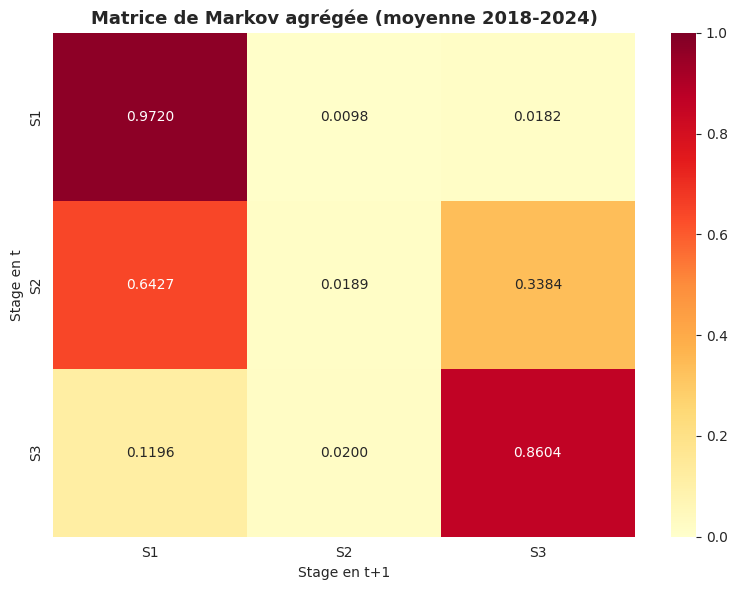

In [24]:
# Visualisation de la matrice de Markov
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(M_markov, annot=True, fmt='.4f', cmap='YlOrRd',
            vmin=0, vmax=1, cbar=True,
            xticklabels=['S1', 'S2', 'S3'], yticklabels=['S1', 'S2', 'S3'], ax=ax)
ax.set_title('Matrice de Markov agrégée (moyenne 2018-2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Stage en t+1')
ax.set_ylabel('Stage en t')
plt.tight_layout()
plt.show()

### 4.2 Distribution initiale du portefeuille

On part de la **structure observée en fin de période 2024** (4ème trimestre) comme point de départ de la projection.

In [25]:
# Structure du portefeuille en T4 2024 (estimation à partir des données)
# Les chiffres ci-dessous sont des ordres de grandeur cohérents avec les observations 2018-2024
pi_0 = np.array([0.80, 0.02, 0.18])  # [S1, S2, S3]

print("Distribution initiale (T4 2024) :")
print(f"  S1 : {pi_0[0]*100:.1f} %")
print(f"  S2 : {pi_0[1]*100:.1f} %")
print(f"  S3 : {pi_0[2]*100:.1f} %")
print(f"  Total : {pi_0.sum()*100:.1f} %")

Distribution initiale (T4 2024) :
  S1 : 80.0 %
  S2 : 2.0 %
  S3 : 18.0 %
  Total : 100.0 %


### 4.3 Projection sur 25 ans

La propriété fondamentale des chaînes de Markov permet de calculer la distribution future :

$$\pi_n = \pi_0 \cdot M^n$$

où $M^n$ est la $n$-ième puissance matricielle de $M$, et $\pi_n$ représente la distribution des stages après $n$ années.



In [26]:
# Conversion de la matrice de Markov en numpy pour la puissance matricielle
M_np = M_markov.values  # Matrice (3, 3)

# Horizon de projection
n_years = 25
trajectoire = np.zeros((n_years + 1, 3))
trajectoire[0] = pi_0

# Itération : pi_{n+1} = pi_n @ M
for t in range(1, n_years + 1):
    trajectoire[t] = trajectoire[t-1] @ M_np

# Construction d'un DataFrame pour faciliter la lecture
df_proj = pd.DataFrame(trajectoire,
                       columns=['S1', 'S2', 'S3'],
                       index=range(2024, 2024 + n_years + 1))
df_proj.index.name = 'Année'

print("Projection sur 25 ans (échantillon) :")
print(df_proj.iloc[[0, 1, 2, 5, 10, 15, 20, 25]].round(4))

Projection sur 25 ans (échantillon) :
          S1     S2     S3
Année                     
2024  0.8000 0.0200 0.1800
2025  0.8120 0.0118 0.1762
2026  0.8179 0.0117 0.1704
2029  0.8307 0.0116 0.1577
2034  0.8419 0.0114 0.1467
2039  0.8467 0.0114 0.1419
2044  0.8488 0.0113 0.1398
2049  0.8497 0.0113 0.1389


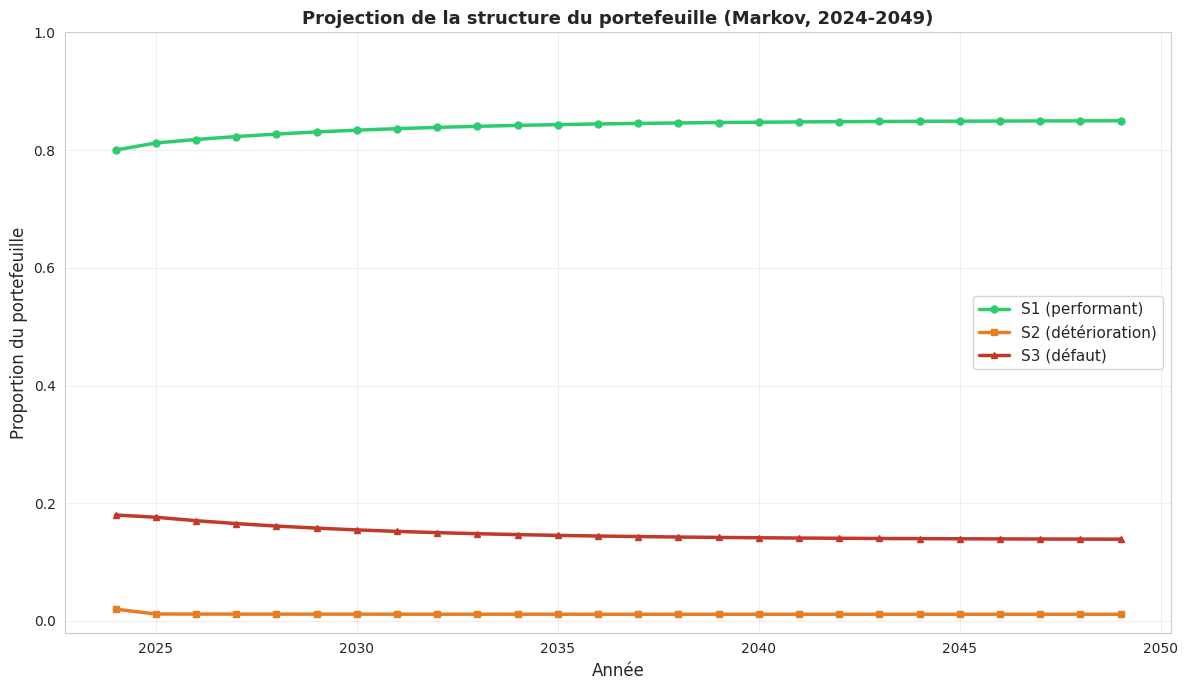

In [27]:
# Visualisation de la trajectoire projetée
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(df_proj.index, df_proj['S1'], 'o-', label='S1 (performant)',
        color='#2ecc71', linewidth=2.5, markersize=5)
ax.plot(df_proj.index, df_proj['S2'], 's-', label='S2 (détérioration)',
        color='#e67e22', linewidth=2.5, markersize=5)
ax.plot(df_proj.index, df_proj['S3'], '^-', label='S3 (défaut)',
        color='#c0392b', linewidth=2.5, markersize=5)

ax.set_xlabel('Année', fontsize=12)
ax.set_ylabel('Proportion du portefeuille', fontsize=12)
ax.set_title('Projection de la structure du portefeuille (Markov, 2024-2049)',
             fontsize=13, fontweight='bold')
ax.legend(loc='center right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.02, 1.0)

plt.tight_layout()
plt.show()

## 5. Conclusion

Ce travail a permis d'estimer sept matrices de transition annuelles entre les stages IFRS 9 du portefeuille de la Banque de Tunisie sur la période 2018-2024, puis d'utiliser un modèle de Markov pour projeter l'évolution du portefeuille à vingt-cinq ans. Les résultats montrent que les clients en stage 1 restent en grande majorité performants d'une année sur l'autre, avec une probabilité de maintien d'environ 97 %, tandis que les clients en stage 3 sortent difficilement du défaut, avec une probabilité d'y rester comprise entre 85 % et 88 %. On observe également une amélioration nette des recouvrements à partir de 2022, la probabilité de passer de S3 à S1 passant d'environ 9 % à près de 16 %, ce qui peut s'expliquer par la fin des moratoires liés à la crise sanitaire et par une politique de recouvrement plus active.

Ce stage a été l'occasion de mettre en pratique des notions vues en cours — probabilités, chaînes de Markov, manipulation de données en Python — sur un cas concret du secteur bancaire. Le modèle reste simple et présente plusieurs limites, notamment l'hypothèse que les transitions ne dépendent que de l'état actuel du client et la supposition que les comportements restent stables dans le temps. Des prolongements seraient envisageables, comme l'intégration de variables explicatives (montant du crédit, profil du client) ou la prise en compte du contexte macroéconomique pour rendre les projections plus réalistes.

---

## Références

- **IFRS 9 — Financial Instruments**, IASB (2014).
- Jarrow, R., Lando, D., Turnbull, S. (1997). *A Markov Model for the Term Structure of Credit Risk Spreads*. Review of Financial Studies, 10(2), 481-523.
- Schuermann, T., Jafry, Y. (2003). *Measurement and Estimation of Credit Migration Matrices*. Wharton Financial Institutions Center.
- Banque Centrale de Tunisie, *Circulaire n°2020-06* relative aux mesures de soutien aux entreprises affectées par la pandémie.

---

*Notebook réalisé dans le cadre du stage à la Banque de Tunisie, Direction du Risque (Juillet 2025). Toute donnée client a été anonymisée ou retirée pour la version publique.*

**Contact :** Youssef Rais — raisyoussef456@gmail.com — [GitHub](https://github.com/raisy5)